PROJECT

   QUANTITYORDERED  PRICEEACH  MSRP    SALES
0               30      95.70    95  2871.00
1               34      81.35    95  2765.90
2               41      94.74    95  3884.34
3               45      83.26    95  3746.70
4               49     100.00    95  5205.27


C:\Users\ASUSS\AppData\Local\Temp\ipykernel_10368\361790359.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


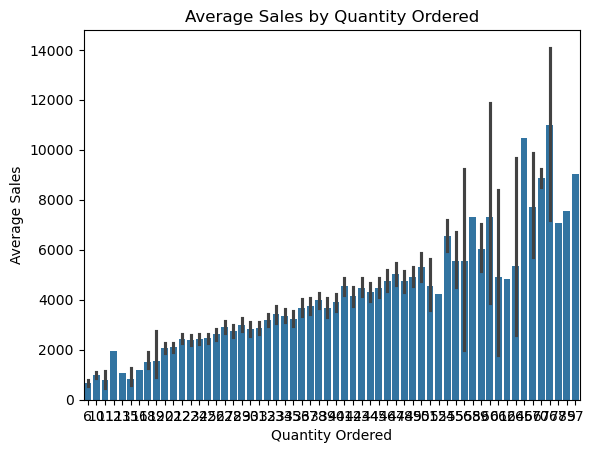

   QUANTITYORDERED  PRICEEACH      MSRP    SALES
0        -0.522891   0.596978 -0.142246  2871.00
1        -0.112201  -0.114450 -0.142246  2765.90
2         0.606505   0.549384 -0.142246  3884.34
3         1.017195  -0.019759 -0.142246  3746.70
4         1.427884   0.810158 -0.142246  5205.27
Predicted Sales = [4812.29968602]


['sales_model.joblib']

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

import pymysql
import joblib

# Connect MySQL
conn = pymysql.connect(
    host="localhost",
    user="root",
    password="Shreya@2006",
    database="sales_db"
)

print(conn)

query = """
SELECT
QUANTITYORDERED,
PRICEEACH,
MSRP,
SALES
FROM sales_data_sample
"""

df = pd.read_sql(query, conn)

print(df.head())

#graph
sns.barplot(
    x="QUANTITYORDERED",
    y="SALES",
    data=df,
    estimator="mean"
)

plt.title("Average Sales by Quantity Ordered")
plt.xlabel("Quantity Ordered")
plt.ylabel("Average Sales")
plt.show()

# Feature Scaling
scalar = StandardScaler()
df[['QUANTITYORDERED','PRICEEACH','MSRP']] = scalar.fit_transform(
    df[['QUANTITYORDERED','PRICEEACH','MSRP']]
)

print(df.head())

# Split Data
x = df[['QUANTITYORDERED','PRICEEACH','MSRP']]
y = df['SALES']

# Train Test Split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=2)

# Model Training
model = LinearRegression()
model.fit(x_train, y_train)



# Feature Scaling
new_data[['QUANTITYORDERED','PRICEEACH','MSRP']] = scalar.transform(new_data[['QUANTITYORDERED','PRICEEACH','MSRP']])

# Prediction
predict_data = model.predict(new_data)

print("Predicted Sales =", predict_data)

#  Model dump
joblib.dump(model, "sales_model.joblib")
